In [1]:
import sqlite3
import pandas as pd
import numpy as np

def generate_authentic_petrophysics():
    """Menghasilkan data log sumur berdasarkan prinsip fisika batuan."""
    # Resolusi kedalaman standar log (0.1524 m = 0.5 ft)
    depth = np.arange(1000.0, 1100.0, 0.1524) 
    n_samples = len(depth)
    
    # 1. Membuat Model Litologi (Volume Shale / Vsh) dasar yang "Blocky"
    vsh_true = np.zeros(n_samples)
    vsh_true[0:150] = 0.9    # Zona atas: Shale tebal
    vsh_true[150:300] = 0.05 # Zona tengah: Batupasir sangat bersih
    vsh_true[300:450] = 0.3  # Zona bawah: Shaly Sand (Batupasir lempungan)
    vsh_true[450:] = 0.85    # Zona dasar: Shale
    
    # Tambahkan sedikit noise natural agar tidak kaku
    vsh_true = vsh_true + np.random.normal(0, 0.05, n_samples)
    vsh_true = np.clip(vsh_true, 0, 1)
    
    # 2. Sintesis Log GR
    gr_clean, gr_shale = 20, 120
    gr_log = gr_clean + vsh_true * (gr_shale - gr_clean) + np.random.normal(0, 2, n_samples)
    
    # 3. Sintesis Porositas Total (Phi)
    # Asumsi: Sandstone phi ~25%, Shale phi ~5%
    phi_true = 0.25 - (0.20 * vsh_true) + np.random.normal(0, 0.01, n_samples)
    phi_true = np.clip(phi_true, 0.01, 0.4)
    
    # 4. Sintesis Log RHOB dan NPHI
    rho_ma, rho_fl = 2.65, 1.0 # Matriks Sandstone dan Air
    rhob_log = (phi_true * rho_fl) + ((1 - phi_true) * rho_ma) + np.random.normal(0, 0.02, n_samples)
    
    # Neutron Log (NPHI) biasanya membaca terlalu tinggi di zona shale karena air terikat (bound water)
    nphi_log = phi_true + (vsh_true * 0.25) + np.random.normal(0, 0.01, n_samples)
    
    # 5. Menentukan Zona Fluida (Saturasi Air / Sw)
    sw_true = np.ones(n_samples) # Default: 100% Air (Sw = 1)
    # Kita buat Batupasir bersih (index 150-250) mengandung Minyak (Sw = 20%)
    sw_true[150:250] = 0.2 
    
    # 6. Sintesis Log Resistivitas (RT) menggunakan Persamaan Archie terbalik
    a, m, n, rw = 1.0, 2.0, 2.0, 0.1
    rt_log = (a * rw) / ((phi_true ** m) * (sw_true ** n))
    rt_log = rt_log + np.random.normal(0, rt_log * 0.05) # Noise proporsional
    rt_log = np.clip(rt_log, 0.2, 2000) # Batas wajar alat logging
    
    # --- BUNGKUS KE DALAM DATAFRAME ---
    df_logs = pd.DataFrame({
        'Well_ID': 'WELL-ML-01',
        'Depth': depth,
        'GR': np.round(gr_log, 2),
        'RHOB': np.round(rhob_log, 3),
        'NPHI': np.round(nphi_log, 3),
        'RT': np.round(rt_log, 2)
    })
    
    # --- BUAT DATA CORE (GROUND TRUTH) ---
    # Kita ambil sampel "Core" di beberapa kedalaman acak untuk dijadikan target ML
    core_indices = [160, 200, 320, 400, 500]
    df_core = pd.DataFrame({
        'Well_ID': 'WELL-ML-01',
        'Depth': depth[core_indices],
        'Core_Porosity': np.round(phi_true[core_indices], 3),
        'Lithology_Label': ['Sandstone' if v < 0.3 else 'Shaly Sand' if v < 0.6 else 'Shale' for v in vsh_true[core_indices]]
    })
    
    return df_logs, df_core

def simpan_ke_database(df_logs, df_core, db_name="petrofisika_ml.db"):
    """Menyimpan DataFrame ke SQLite."""
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    
    # Pastikan tabel Well_Header ada dan masukkan data sumur baru
    cursor.execute('''CREATE TABLE IF NOT EXISTS Well_Header (Well_ID TEXT PRIMARY KEY, Field_Name TEXT, Mud_Type TEXT)''')
    cursor.execute("INSERT OR IGNORE INTO Well_Header VALUES ('WELL-ML-01', 'Synthetic Basin', 'WBM')")
    
    # Simpan data
    df_logs.to_sql('Well_Logs', conn, if_exists='replace', index=False)
    df_core.to_sql('Core_Data', conn, if_exists='replace', index=False)
    
    conn.commit()
    conn.close()
    print("Data autentik berbasis fisika berhasil di-generate dan disimpan ke database!")

# --- EKSEKUSI ---
df_logs_auth, df_core_auth = generate_authentic_petrophysics()
simpan_ke_database(df_logs_auth, df_core_auth)

# Tampilkan cuplikan data
print("\nCuplikan Data Log (Fitur AI):")
print(df_logs_auth.head())
print("\nCuplikan Data Core (Target AI):")
print(df_core_auth)

Data autentik berbasis fisika berhasil di-generate dan disimpan ke database!

Cuplikan Data Log (Fitur AI):
      Well_ID      Depth      GR   RHOB   NPHI     RT
0  WELL-ML-01  1000.0000  115.31  2.576  0.290  51.29
1  WELL-ML-01  1000.1524   99.81  2.552  0.295  13.48
2  WELL-ML-01  1000.3048  110.04  2.530  0.308  13.89
3  WELL-ML-01  1000.4572  101.93  2.495  0.325  11.53
4  WELL-ML-01  1000.6096  102.70  2.479  0.317  10.86

Cuplikan Data Core (Target AI):
      Well_ID     Depth  Core_Porosity Lithology_Label
0  WELL-ML-01  1024.384          0.240       Sandstone
1  WELL-ML-01  1030.480          0.244       Sandstone
2  WELL-ML-01  1048.768          0.194      Shaly Sand
3  WELL-ML-01  1060.960          0.187      Shaly Sand
4  WELL-ML-01  1076.200          0.089           Shale


[1/3] Menghasilkan data log petrofisika sintetik...
[2/3] Menyimpan data ke file 'Database_Petrofisika_ML.xlsx'...
      File Excel berhasil dibuat!
[3/3] Menyiapkan visualisasi grafik...
      Menampilkan grafik... (Tutup jendela grafik untuk mengakhiri program)


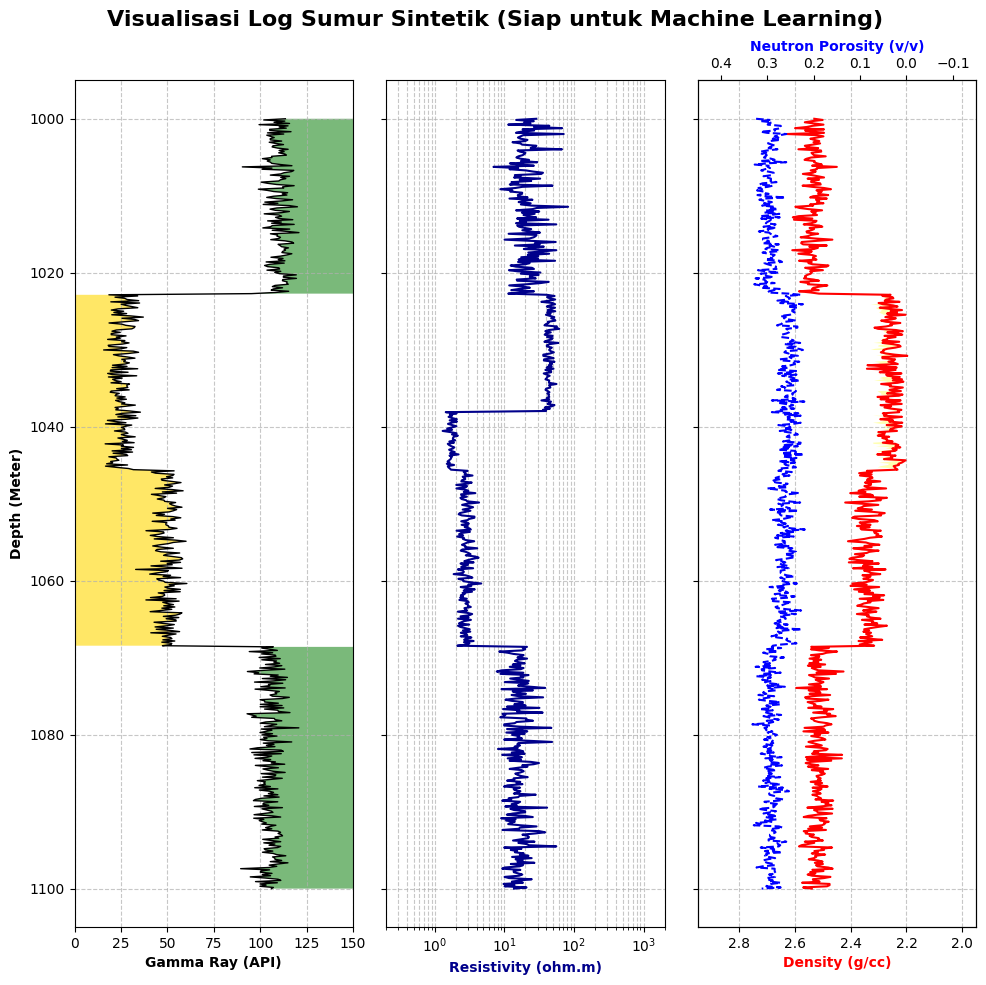


[SELESAI] Seluruh alur kerja telah sukses dijalankan!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. FUNGSI PEMBUATAN DATA
# ==========================================
def generate_authentic_petrophysics():
    print("[1/3] Menghasilkan data log petrofisika sintetik...")
    depth = np.arange(1000.0, 1100.0, 0.1524) 
    n_samples = len(depth)
    
    # Model Litologi (Vsh)
    vsh_true = np.zeros(n_samples)
    vsh_true[0:150] = 0.9    # Zona atas: Shale
    vsh_true[150:300] = 0.05 # Zona tengah: Reservoir (Batupasir Bersih)
    vsh_true[300:450] = 0.3  # Zona bawah: Shaly Sand
    vsh_true[450:] = 0.85    # Zona dasar: Shale
    vsh_true = np.clip(vsh_true + np.random.normal(0, 0.05, n_samples), 0, 1)
    
    # Log Fisika
    gr_log = 20 + vsh_true * 100 + np.random.normal(0, 2, n_samples)
    phi_true = np.clip(0.25 - (0.20 * vsh_true) + np.random.normal(0, 0.01, n_samples), 0.01, 0.4)
    rhob_log = (phi_true * 1.0) + ((1 - phi_true) * 2.65) + np.random.normal(0, 0.02, n_samples)
    nphi_log = phi_true + (vsh_true * 0.25) + np.random.normal(0, 0.01, n_samples)
    
    # Saturasi Air & Resistivitas
    sw_true = np.ones(n_samples) 
    sw_true[150:250] = 0.2 # Hidrokarbon di zona reservoir
    rt_log = np.clip((1.0 * 0.1) / ((phi_true ** 2) * (sw_true ** 2)), 0.2, 2000)
    rt_log = rt_log + np.random.normal(0, rt_log * 0.05)
    
    df_logs = pd.DataFrame({
        'Well_ID': 'WELL-ML-01', 'Depth': depth,
        'GR': np.round(gr_log, 2), 'RHOB': np.round(rhob_log, 3),
        'NPHI': np.round(nphi_log, 3), 'RT': np.round(rt_log, 2)
    })
    
    core_indices = [160, 200, 320, 400, 500]
    df_core = pd.DataFrame({
        'Well_ID': 'WELL-ML-01', 'Depth': depth[core_indices],
        'Core_Porosity': np.round(phi_true[core_indices], 3),
        'Lithology_Label': ['Sandstone' if v < 0.3 else 'Shaly Sand' if v < 0.6 else 'Shale' for v in vsh_true[core_indices]]
    })
    
    return df_logs, df_core

# ==========================================
# 2. FUNGSI PENYIMPANAN DATA EXCEL
# ==========================================
def simpan_ke_excel(df_logs, df_core, nama_file="Database_Petrofisika_ML.xlsx"):
    print(f"[2/3] Menyimpan data ke file '{nama_file}'...")
    with pd.ExcelWriter(nama_file, engine='openpyxl') as writer:
        df_logs.to_excel(writer, sheet_name='Well_Logs', index=False)
        df_core.to_excel(writer, sheet_name='Core_Data', index=False)
    print("      File Excel berhasil dibuat!")

# ==========================================
# 3. FUNGSI VISUALISASI LOG SUMUR
# ==========================================
def visualisasi_log_sumur(nama_file="Database_Petrofisika_ML.xlsx"):
    print("[3/3] Menyiapkan visualisasi grafik...")
    df = pd.read_excel(nama_file, sheet_name='Well_Logs')

    fig, axes = plt.subplots(figsize=(10, 10), ncols=3, sharey=True)
    fig.suptitle('Visualisasi Log Sumur Sintetik (Siap untuk Machine Learning)', fontsize=16, fontweight='bold', y=0.98)

    # Track 1: GR
    ax0 = axes[0]
    ax0.plot(df['GR'], df['Depth'], color='black', linewidth=1)
    ax0.set_xlabel('Gamma Ray (API)', fontweight='bold')
    ax0.set_xlim(0, 150)
    ax0.set_ylabel('Depth (Meter)', fontweight='bold')
    ax0.invert_yaxis()
    ax0.grid(True, linestyle='--', alpha=0.7)
    ax0.fill_betweenx(df['Depth'], 0, df['GR'], where=(df['GR'] <= 65), facecolor='gold', alpha=0.6)
    ax0.fill_betweenx(df['Depth'], df['GR'], 150, where=(df['GR'] > 65), facecolor='forestgreen', alpha=0.6)

    # Track 2: RT
    ax1 = axes[1]
    ax1.plot(df['RT'], df['Depth'], color='darkblue', linewidth=1.5)
    ax1.set_xlabel('Resistivity (ohm.m)', color='darkblue', fontweight='bold')
    ax1.set_xlim(0.2, 2000)
    ax1.set_xscale('log')
    ax1.grid(True, which='both', linestyle='--', alpha=0.7)

    # Track 3: RHOB & NPHI
    ax2 = axes[2]
    ax2.plot(df['RHOB'], df['Depth'], color='red', linewidth=1.5, label='RHOB')
    ax2.set_xlabel('Density (g/cc)', color='red', fontweight='bold')
    ax2.set_xlim(1.95, 2.95)
    ax2.invert_xaxis()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    ax3 = ax2.twiny()
    ax3.plot(df['NPHI'], df['Depth'], color='blue', linestyle='--', linewidth=1.5, label='NPHI')
    ax3.set_xlabel('Neutron Porosity (v/v)', color='blue', fontweight='bold')
    ax3.set_xlim(0.45, -0.15)
    
    # Efek Crossover (Arsiran Kuning antara RHOB dan NPHI)
    x1_rhob = df['RHOB']
    x2_nphi_scaled = 1.95 + (0.45 - df['NPHI']) / (0.45 - (-0.15)) * (2.95 - 1.95)
    ax2.fill_betweenx(df['Depth'], x1_rhob, x2_nphi_scaled, where=(x1_rhob < x2_nphi_scaled), facecolor='yellow', alpha=0.3)

    plt.tight_layout()
    print("      Menampilkan grafik... (Tutup jendela grafik untuk mengakhiri program)")
    plt.show()

# ==========================================
# BLOK EKSEKUSI UTAMA (MAIN RUN)
# ==========================================
if __name__ == "__main__":
    nama_file_excel = "Database_Petrofisika_ML.xlsx"
    
    # 1. Generate Data
    df_logs, df_core = generate_authentic_petrophysics()
    
    # 2. Simpan Data
    simpan_ke_excel(df_logs, df_core, nama_file_excel)
    
    # 3. Visualisasikan Data
    visualisasi_log_sumur(nama_file_excel)
    
    print("\n[SELESAI] Seluruh alur kerja telah sukses dijalankan!")

[1/3] Menghasilkan BIG DATA log petrofisika (Kedalaman 1000m - 3000m)...
      Berhasil! 13124 baris Log dan 150 baris Core dibuat.
[2/3] Menyimpan data raksasa ke 'Big_Data_Petrofisika.xlsx' (Mungkin butuh beberapa detik)...
      Selesai disimpan!
[3/3] Memplot cuplikan kedalaman 1500m - 1700m...


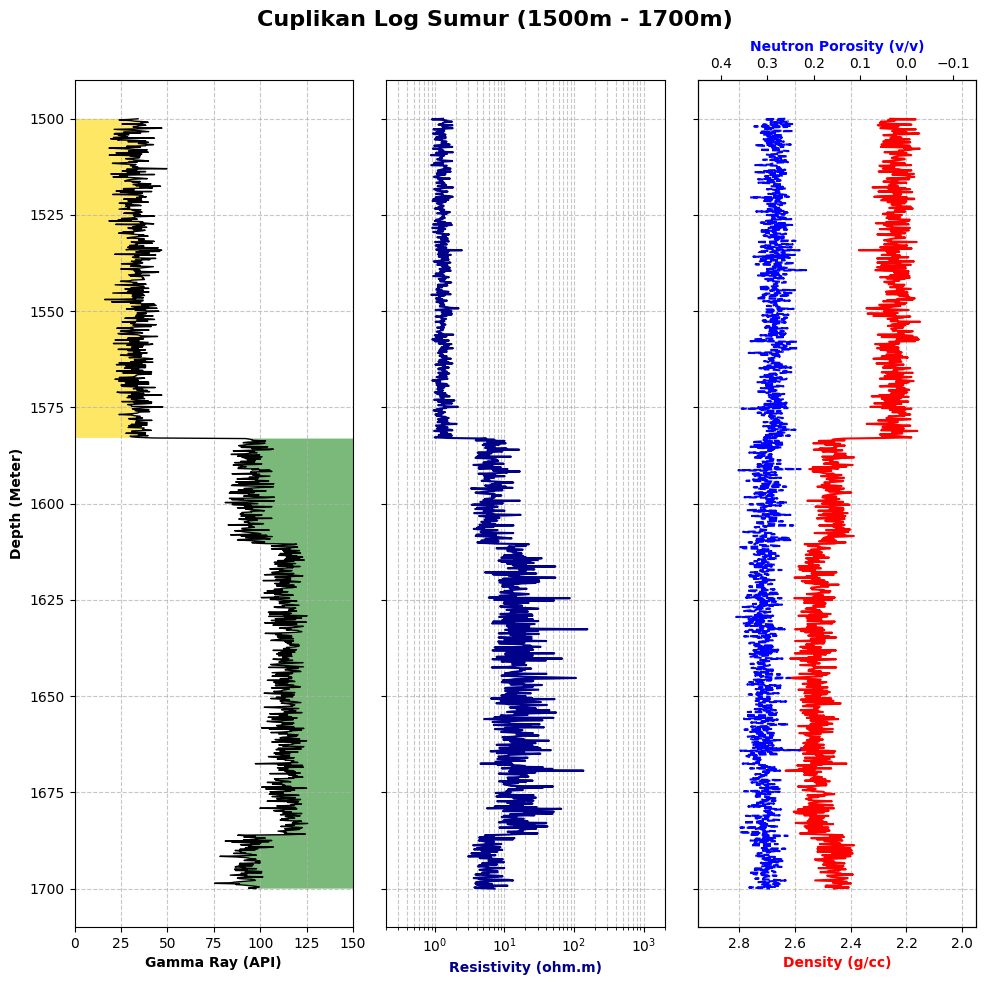

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. FUNGSI PEMBUATAN BIG DATA
# ==========================================
def generate_massive_petrophysics():
    print("[1/3] Menghasilkan BIG DATA log petrofisika (Kedalaman 1000m - 3000m)...")
    
    # Resolusi 0.1524 m selama 2000 meter menghasilkan ~13.123 baris data
    depth = np.arange(1000.0, 3000.0, 0.1524) 
    n_samples = len(depth)
    
    vsh_true = np.zeros(n_samples)
    sw_true = np.ones(n_samples) # Default 100% Air
    
    # Membuat perlapisan geologi secara acak
    current_idx = 0
    while current_idx < n_samples:
        # Ketebalan lapisan acak antara 15 meter hingga 75 meter (100 - 500 sampel)
        layer_thickness = np.random.randint(100, 500) 
        end_idx = min(current_idx + layer_thickness, n_samples)
        
        # Probabilitas: 50% Shale, 30% Sand, 20% Shaly Sand
        lith_type = np.random.choice(['Shale', 'Sand', 'ShalySand'], p=[0.5, 0.3, 0.2])
        
        if lith_type == 'Shale':
            vsh_true[current_idx:end_idx] = np.random.uniform(0.7, 0.95)
        elif lith_type == 'Sand':
            vsh_true[current_idx:end_idx] = np.random.uniform(0.05, 0.2)
            # 40% kemungkinan Sandstone ini mengandung Minyak/Gas
            if np.random.rand() > 0.6: 
                sw_true[current_idx:end_idx] = np.random.uniform(0.15, 0.3)
        else: # Shaly Sand
            vsh_true[current_idx:end_idx] = np.random.uniform(0.3, 0.6)
            
        current_idx = end_idx

    # Tambahkan noise agar terlihat seperti kurva asli
    vsh_true = np.clip(vsh_true + np.random.normal(0, 0.05, n_samples), 0, 1)
    
    # Menghitung Log Fisika
    gr_log = 20 + vsh_true * 100 + np.random.normal(0, 3, n_samples)
    phi_true = np.clip(0.28 - (0.22 * vsh_true) + np.random.normal(0, 0.015, n_samples), 0.01, 0.4)
    rhob_log = (phi_true * 1.0) + ((1 - phi_true) * 2.65) + np.random.normal(0, 0.02, n_samples)
    nphi_log = phi_true + (vsh_true * 0.25) + np.random.normal(0, 0.015, n_samples)
    
    # Menghitung Resistivitas (Persamaan Archie)
    rt_log = np.clip((1.0 * 0.08) / ((phi_true ** 2) * (sw_true ** 2)), 0.2, 2000)
    rt_log = rt_log + np.random.normal(0, rt_log * 0.05)
    
    # Menyusun DataFrame Log
    df_logs = pd.DataFrame({
        'Well_ID': 'WELL-BIG-01', 'Depth': depth,
        'GR': np.round(gr_log, 2), 'RHOB': np.round(rhob_log, 3),
        'NPHI': np.round(nphi_log, 3), 'RT': np.round(rt_log, 2)
    })
    
    # Membuat 150 titik Data Core secara acak sebagai Target AI
    core_indices = np.random.choice(n_samples, size=150, replace=False)
    core_indices.sort()
    df_core = pd.DataFrame({
        'Well_ID': 'WELL-BIG-01', 'Depth': depth[core_indices],
        'Core_Porosity': np.round(phi_true[core_indices], 3),
        'Lithology_Label': ['Sandstone' if v < 0.3 else 'Shaly Sand' if v < 0.6 else 'Shale' for v in vsh_true[core_indices]]
    })
    
    print(f"      Berhasil! {len(df_logs)} baris Log dan {len(df_core)} baris Core dibuat.")
    return df_logs, df_core

# ==========================================
# 2. FUNGSI PENYIMPANAN DATA EXCEL
# ==========================================
def simpan_ke_excel(df_logs, df_core, nama_file="Big_Data_Petrofisika.xlsx"):
    print(f"[2/3] Menyimpan data raksasa ke '{nama_file}' (Mungkin butuh beberapa detik)...")
    with pd.ExcelWriter(nama_file, engine='openpyxl') as writer:
        df_logs.to_excel(writer, sheet_name='Well_Logs', index=False)
        df_core.to_excel(writer, sheet_name='Core_Data', index=False)
    print("      Selesai disimpan!")

# ==========================================
# 3. FUNGSI VISUALISASI (ZOOM IN)
# ==========================================
def visualisasi_log_zoom(nama_file="Big_Data_Petrofisika.xlsx", depth_start=1500, depth_end=1700):
    print(f"[3/3] Memplot cuplikan kedalaman {depth_start}m - {depth_end}m...")
    df = pd.read_excel(nama_file, sheet_name='Well_Logs')
    
    # Filter data hanya untuk divisualisasikan agar tidak terlalu padat
    df_plot = df[(df['Depth'] >= depth_start) & (df['Depth'] <= depth_end)]

    fig, axes = plt.subplots(figsize=(10, 10), ncols=3, sharey=True)
    fig.suptitle(f'Cuplikan Log Sumur ({depth_start}m - {depth_end}m)', fontsize=16, fontweight='bold', y=0.98)

    # Track 1: GR
    ax0 = axes[0]
    ax0.plot(df_plot['GR'], df_plot['Depth'], color='black', linewidth=1)
    ax0.set_xlabel('Gamma Ray (API)', fontweight='bold')
    ax0.set_xlim(0, 150)
    ax0.set_ylabel('Depth (Meter)', fontweight='bold')
    ax0.invert_yaxis()
    ax0.grid(True, linestyle='--', alpha=0.7)
    ax0.fill_betweenx(df_plot['Depth'], 0, df_plot['GR'], where=(df_plot['GR'] <= 65), facecolor='gold', alpha=0.6)
    ax0.fill_betweenx(df_plot['Depth'], df_plot['GR'], 150, where=(df_plot['GR'] > 65), facecolor='forestgreen', alpha=0.6)

    # Track 2: RT
    ax1 = axes[1]
    ax1.plot(df_plot['RT'], df_plot['Depth'], color='darkblue', linewidth=1.5)
    ax1.set_xlabel('Resistivity (ohm.m)', color='darkblue', fontweight='bold')
    ax1.set_xlim(0.2, 2000)
    ax1.set_xscale('log')
    ax1.grid(True, which='both', linestyle='--', alpha=0.7)

    # Track 3: RHOB & NPHI
    ax2 = axes[2]
    ax2.plot(df_plot['RHOB'], df_plot['Depth'], color='red', linewidth=1.5, label='RHOB')
    ax2.set_xlabel('Density (g/cc)', color='red', fontweight='bold')
    ax2.set_xlim(1.95, 2.95)
    ax2.invert_xaxis()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    ax3 = ax2.twiny()
    ax3.plot(df_plot['NPHI'], df_plot['Depth'], color='blue', linestyle='--', linewidth=1.5, label='NPHI')
    ax3.set_xlabel('Neutron Porosity (v/v)', color='blue', fontweight='bold')
    ax3.set_xlim(0.45, -0.15)
    
    # Efek Crossover
    x1_rhob = df_plot['RHOB']
    x2_nphi_scaled = 1.95 + (0.45 - df_plot['NPHI']) / (0.45 - (-0.15)) * (2.95 - 1.95)
    ax2.fill_betweenx(df_plot['Depth'], x1_rhob, x2_nphi_scaled, where=(x1_rhob < x2_nphi_scaled), facecolor='yellow', alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==========================================
# EKSEKUSI
# ==========================================
if __name__ == "__main__":
    nama_excel = "Big_Data_Petrofisika.xlsx"
    df_logs, df_core = generate_massive_petrophysics()
    simpan_ke_excel(df_logs, df_core, nama_excel)
    
    # Karena datanya 2000 meter, kita visualisasikan cuplikan 200 meternya saja 
    # agar grafiknya tidak menjadi blok warna yang padat.
    visualisasi_log_zoom(nama_excel, depth_start=1500, depth_end=1700)

[1/3] Menghasilkan BIG DATA Ultra-Deep (0 - 12.000 meter)...
      Berhasil! 78741 baris Log dan 500 baris Core dibuat.
[2/3] Menyimpan ~78.000 baris ke 'UltraDeep_Petrofisika.xlsx' (Proses ini memakan waktu beberapa detik)...
      Selesai disimpan!
[3/3] Memplot cuplikan zona ekstrem pada kedalaman 10000m - 10200m...


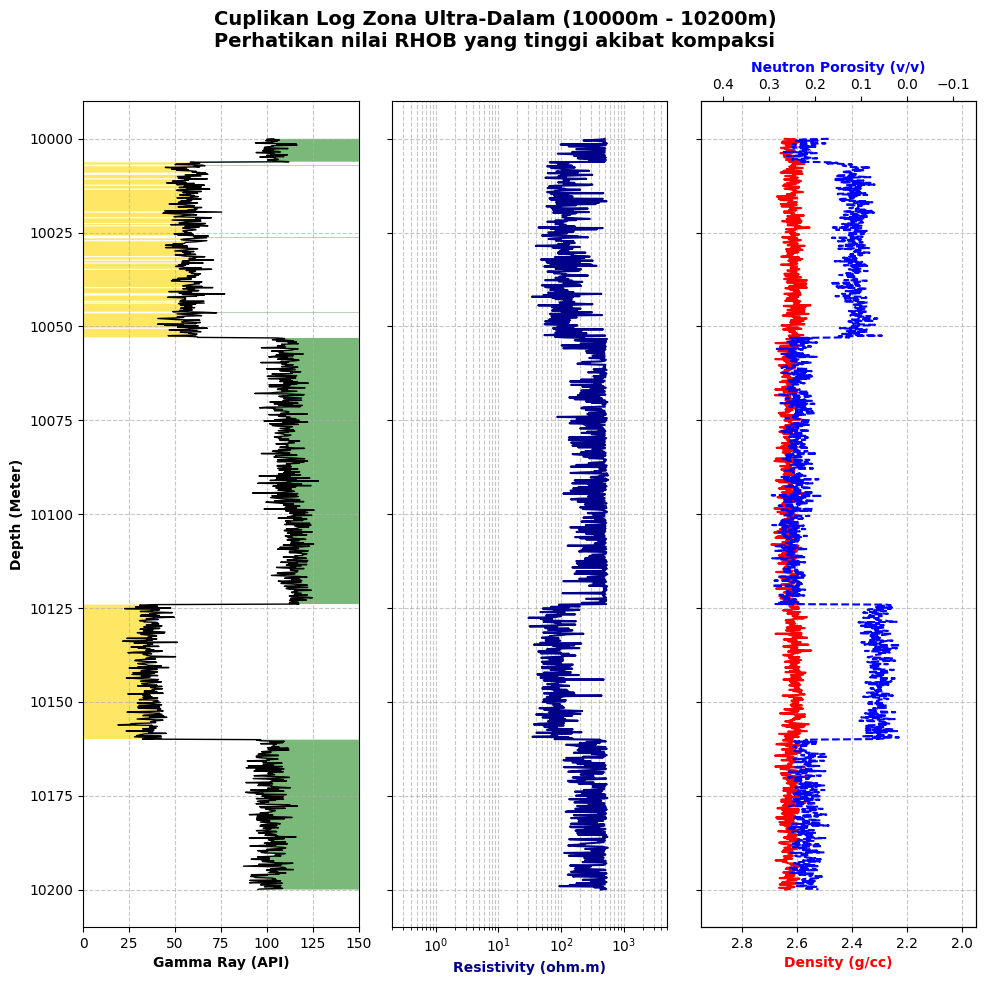


[SELESAI] Pipeline data raksasa telah tereksekusi dengan sempurna!


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. FUNGSI PEMBUATAN DATA (12.000 Meter)
# ==========================================
def generate_ultradeep_petrophysics():
    print("[1/3] Menghasilkan BIG DATA Ultra-Deep (0 - 12.000 meter)...")
    
    # Resolusi 0.1524 m selama 12.000 m -> Menghasilkan ~78.740 baris data
    depth = np.arange(0.0, 12000.0, 0.1524) 
    n_samples = len(depth)
    
    vsh_true = np.zeros(n_samples)
    sw_true = np.ones(n_samples) 
    
    # Membuat Stratigrafi Acak
    current_idx = 0
    while current_idx < n_samples:
        layer_thickness = np.random.randint(50, 400) 
        end_idx = min(current_idx + layer_thickness, n_samples)
        
        lith_type = np.random.choice(['Shale', 'Sand', 'ShalySand'], p=[0.6, 0.25, 0.15])
        
        if lith_type == 'Shale':
            vsh_true[current_idx:end_idx] = np.random.uniform(0.7, 0.95)
        elif lith_type == 'Sand':
            vsh_true[current_idx:end_idx] = np.random.uniform(0.05, 0.2)
            if np.random.rand() > 0.7: # Hidrokarbon
                sw_true[current_idx:end_idx] = np.random.uniform(0.15, 0.4)
        else:
            vsh_true[current_idx:end_idx] = np.random.uniform(0.3, 0.6)
            
        current_idx = end_idx

    vsh_true = np.clip(vsh_true + np.random.normal(0, 0.05, n_samples), 0, 1)
    
    # MENGAPLIKASIKAN EFEK KOMPAKSI (Athy's Law)
    phi_surface = 0.35 - (0.25 * vsh_true) 
    k_compaction = 0.00025 
    # Porositas menurun eksponensial seiring kedalaman
    phi_true = phi_surface * np.exp(-k_compaction * depth) 
    phi_true = np.clip(phi_true + np.random.normal(0, 0.005, n_samples), 0.01, 0.45)
    
    # Menghitung Log Fisika
    gr_log = 20 + vsh_true * 100 + np.random.normal(0, 3, n_samples)
    rhob_log = (phi_true * 1.0) + ((1 - phi_true) * 2.65) + np.random.normal(0, 0.02, n_samples)
    nphi_log = phi_true + (vsh_true * 0.25) + np.random.normal(0, 0.015, n_samples)
    
    # Resistivitas (RT) melonjak di kedalaman ekstrem karena batuan padat
    rt_log = np.clip((1.0 * 0.05) / ((phi_true ** 2) * (sw_true ** 2)), 0.2, 5000)
    rt_log = rt_log + np.random.normal(0, rt_log * 0.05)
    
    df_logs = pd.DataFrame({
        'Well_ID': 'WELL-ULTRA-01', 'Depth': np.round(depth, 4),
        'GR': np.round(gr_log, 2), 'RHOB': np.round(rhob_log, 3),
        'NPHI': np.round(nphi_log, 3), 'RT': np.round(rt_log, 2)
    })
    
    core_indices = np.random.choice(n_samples, size=500, replace=False)
    core_indices.sort()
    df_core = pd.DataFrame({
        'Well_ID': 'WELL-ULTRA-01', 'Depth': np.round(depth[core_indices], 4),
        'Core_Porosity': np.round(phi_true[core_indices], 3),
        'Lithology_Label': ['Sandstone' if v < 0.3 else 'Shaly Sand' if v < 0.6 else 'Shale' for v in vsh_true[core_indices]]
    })
    
    print(f"      Berhasil! {len(df_logs)} baris Log dan {len(df_core)} baris Core dibuat.")
    return df_logs, df_core

# ==========================================
# 2. FUNGSI PENYIMPANAN DATA EXCEL
# ==========================================
def simpan_ke_excel(df_logs, df_core, nama_file="UltraDeep_Petrofisika.xlsx"):
    print(f"[2/3] Menyimpan ~78.000 baris ke '{nama_file}' (Proses ini memakan waktu beberapa detik)...")
    with pd.ExcelWriter(nama_file, engine='openpyxl') as writer:
        df_logs.to_excel(writer, sheet_name='Well_Logs', index=False)
        df_core.to_excel(writer, sheet_name='Core_Data', index=False)
    print("      Selesai disimpan!")

# ==========================================
# 3. FUNGSI VISUALISASI LOG SUMUR (ZOOM)
# ==========================================
def visualisasi_log_zoom(nama_file="UltraDeep_Petrofisika.xlsx", depth_start=10000, depth_end=10200):
    print(f"[3/3] Memplot cuplikan zona ekstrem pada kedalaman {depth_start}m - {depth_end}m...")
    df = pd.read_excel(nama_file, sheet_name='Well_Logs')
    
    # Memotong data sesuai kedalaman yang diminta
    df_plot = df[(df['Depth'] >= depth_start) & (df['Depth'] <= depth_end)]

    if df_plot.empty:
        print("Data pada rentang kedalaman tersebut tidak ditemukan.")
        return

    fig, axes = plt.subplots(figsize=(10, 10), ncols=3, sharey=True)
    fig.suptitle(f'Cuplikan Log Zona Ultra-Dalam ({depth_start}m - {depth_end}m)\nPerhatikan nilai RHOB yang tinggi akibat kompaksi', fontsize=14, fontweight='bold', y=0.98)

    # Track 1: GR
    ax0 = axes[0]
    ax0.plot(df_plot['GR'], df_plot['Depth'], color='black', linewidth=1)
    ax0.set_xlabel('Gamma Ray (API)', fontweight='bold')
    ax0.set_xlim(0, 150)
    ax0.set_ylabel('Depth (Meter)', fontweight='bold')
    ax0.invert_yaxis()
    ax0.grid(True, linestyle='--', alpha=0.7)
    ax0.fill_betweenx(df_plot['Depth'], 0, df_plot['GR'], where=(df_plot['GR'] <= 65), facecolor='gold', alpha=0.6)
    ax0.fill_betweenx(df_plot['Depth'], df_plot['GR'], 150, where=(df_plot['GR'] > 65), facecolor='forestgreen', alpha=0.6)

    # Track 2: RT (Resistivitas di zona dalam akan sangat tinggi)
    ax1 = axes[1]
    ax1.plot(df_plot['RT'], df_plot['Depth'], color='darkblue', linewidth=1.5)
    ax1.set_xlabel('Resistivity (ohm.m)', color='darkblue', fontweight='bold')
    ax1.set_xlim(0.2, 5000) # Batas diubah hingga 5000 karena batuan sangat padat
    ax1.set_xscale('log')
    ax1.grid(True, which='both', linestyle='--', alpha=0.7)

    # Track 3: RHOB & NPHI
    ax2 = axes[2]
    ax2.plot(df_plot['RHOB'], df_plot['Depth'], color='red', linewidth=1.5, label='RHOB')
    ax2.set_xlabel('Density (g/cc)', color='red', fontweight='bold')
    ax2.set_xlim(1.95, 2.95)
    ax2.invert_xaxis()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    ax3 = ax2.twiny()
    ax3.plot(df_plot['NPHI'], df_plot['Depth'], color='blue', linestyle='--', linewidth=1.5, label='NPHI')
    ax3.set_xlabel('Neutron Porosity (v/v)', color='blue', fontweight='bold')
    ax3.set_xlim(0.45, -0.15)
    
    # Efek Crossover
    x1_rhob = df_plot['RHOB']
    x2_nphi_scaled = 1.95 + (0.45 - df_plot['NPHI']) / (0.45 - (-0.15)) * (2.95 - 1.95)
    ax2.fill_betweenx(df_plot['Depth'], x1_rhob, x2_nphi_scaled, where=(x1_rhob < x2_nphi_scaled), facecolor='yellow', alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==========================================
# BLOK EKSEKUSI UTAMA
# ==========================================
if __name__ == "__main__":
    nama_excel = "UltraDeep_Petrofisika.xlsx"
    
    # 1. Generate Data
    df_logs, df_core = generate_ultradeep_petrophysics()
    
    # 2. Simpan Data
    simpan_ke_excel(df_logs, df_core, nama_excel)
    
    # 3. Visualisasikan Data (Memilih zona 10.000 - 10.200 meter)
    visualisasi_log_zoom(nama_excel, depth_start=10000, depth_end=10200)
    
    print("\n[SELESAI] Pipeline data raksasa telah tereksekusi dengan sempurna!")

[1/3] Menghasilkan BIG DATA Multi-Fasies Kompleks (0 - 12.000 meter)...
      Selesai! 78741 baris Log Multi-Fasies dibuat.
[2/3] Menyimpan ~78.000 baris ke 'MultiFacies_Petrofisika.xlsx' (Proses ini memakan waktu beberapa detik)...
      Selesai disimpan!
[3/3] Memplot visualisasi log dasar pada kedalaman 10000m - 10300m...


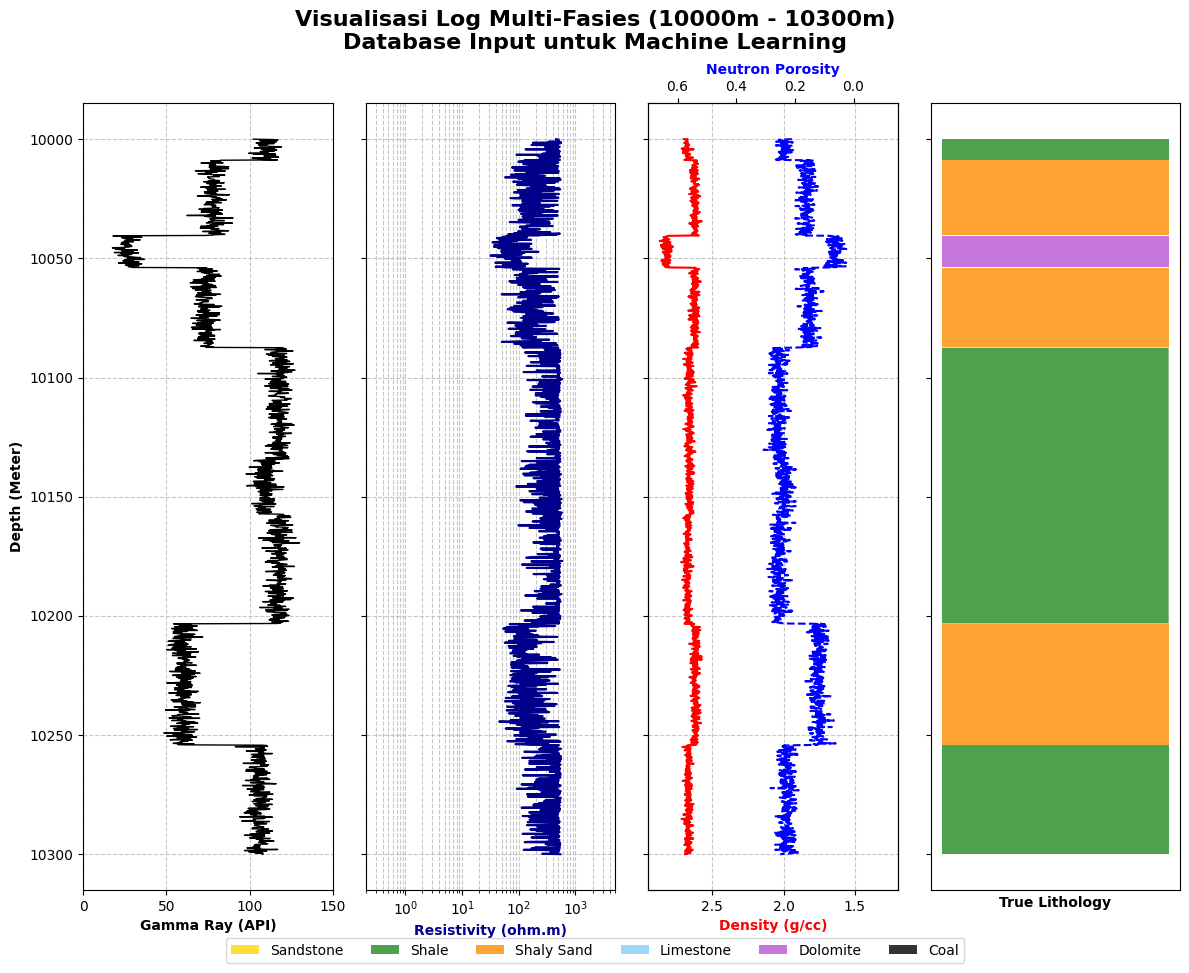


[SELESAI] Database Input siap diproses oleh Machine Learning!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. FUNGSI PEMBUATAN DATA (6 FASIES + KOMPAKSI)
# ==========================================
def generate_multifacies_petrophysics():
    print("[1/3] Menghasilkan BIG DATA Multi-Fasies Kompleks (0 - 12.000 meter)...")
    
    depth = np.arange(0.0, 12000.0, 0.1524) 
    n_samples = len(depth)
    
    vsh_true = np.zeros(n_samples)
    sw_true = np.ones(n_samples) 
    rho_ma_array = np.full(n_samples, 2.65) 
    lithology_labels = np.empty(n_samples, dtype=object) 
    
    current_idx = 0
    while current_idx < n_samples:
        layer_thickness = np.random.randint(50, 400) 
        end_idx = min(current_idx + layer_thickness, n_samples)
        
        # Probabilitas 6 Jenis Batuan
        lith_type = np.random.choice(
            ['Shale', 'Sandstone', 'Shaly Sand', 'Limestone', 'Dolomite', 'Coal'], 
            p=[0.45, 0.20, 0.15, 0.10, 0.05, 0.05]
        )
        
        lithology_labels[current_idx:end_idx] = lith_type
        
        if lith_type == 'Shale':
            vsh_true[current_idx:end_idx] = np.random.uniform(0.7, 1.0)
            rho_ma_array[current_idx:end_idx] = np.random.uniform(2.65, 2.70)
        elif lith_type == 'Sandstone':
            vsh_true[current_idx:end_idx] = np.random.uniform(0.0, 0.15)
            rho_ma_array[current_idx:end_idx] = 2.65 
            if np.random.rand() > 0.6: 
                sw_true[current_idx:end_idx] = np.random.uniform(0.15, 0.4)
        elif lith_type == 'Shaly Sand':
            vsh_true[current_idx:end_idx] = np.random.uniform(0.2, 0.6)
            rho_ma_array[current_idx:end_idx] = 2.65
        elif lith_type == 'Limestone': 
            vsh_true[current_idx:end_idx] = np.random.uniform(0.0, 0.1)
            rho_ma_array[current_idx:end_idx] = 2.71 
            if np.random.rand() > 0.7: 
                sw_true[current_idx:end_idx] = np.random.uniform(0.2, 0.5)
        elif lith_type == 'Dolomite':
            vsh_true[current_idx:end_idx] = np.random.uniform(0.0, 0.1)
            rho_ma_array[current_idx:end_idx] = 2.87 
        elif lith_type == 'Coal': 
            vsh_true[current_idx:end_idx] = 0.0
            rho_ma_array[current_idx:end_idx] = np.random.uniform(1.2, 1.6) 
            sw_true[current_idx:end_idx] = 1.0 
            
        current_idx = end_idx

    vsh_true = np.clip(vsh_true + np.random.normal(0, 0.03, n_samples), 0, 1)
    
    # EFEK KOMPAKSI (Athy's Law)
    phi_surface = 0.35 - (0.25 * vsh_true) 
    k_compaction = 0.00025 
    phi_true = phi_surface * np.exp(-k_compaction * depth) 
    phi_true = np.clip(phi_true + np.random.normal(0, 0.005, n_samples), 0.01, 0.45)
    phi_true[lithology_labels == 'Coal'] = np.random.uniform(0.02, 0.1, np.sum(lithology_labels == 'Coal'))

    # KALKULASI LOG FISIKA
    gr_log = 20 + vsh_true * 100 + np.random.normal(0, 3, n_samples)
    gr_log[lithology_labels == 'Coal'] = np.random.uniform(10, 25, np.sum(lithology_labels == 'Coal'))
    
    rhob_log = (phi_true * 1.0) + ((1 - phi_true) * rho_ma_array) + np.random.normal(0, 0.015, n_samples)
    
    nphi_log = phi_true + (vsh_true * 0.25) + np.random.normal(0, 0.015, n_samples)
    nphi_log[lithology_labels == 'Limestone'] -= 0.03 
    nphi_log[lithology_labels == 'Dolomite'] += 0.02
    nphi_log[lithology_labels == 'Coal'] = np.random.uniform(0.45, 0.65, np.sum(lithology_labels == 'Coal'))
    
    rt_log = np.clip((1.0 * 0.05) / ((phi_true ** 2) * (sw_true ** 2)), 0.2, 5000)
    rt_log[lithology_labels == 'Coal'] = np.random.uniform(200, 2000, np.sum(lithology_labels == 'Coal')) 
    rt_log = rt_log + np.random.normal(0, rt_log * 0.05)
    
    df_logs = pd.DataFrame({
        'Well_ID': 'WELL-MULTI-01', 'Depth': np.round(depth, 4),
        'GR': np.round(gr_log, 2), 'RHOB': np.round(rhob_log, 3),
        'NPHI': np.round(nphi_log, 3), 'RT': np.round(rt_log, 2),
        'True_Facies': lithology_labels 
    })
    
    core_indices = np.random.choice(n_samples, size=1000, replace=False)
    core_indices.sort()
    df_core = pd.DataFrame({
        'Well_ID': 'WELL-MULTI-01', 'Depth': np.round(depth[core_indices], 4),
        'Core_Porosity': np.round(phi_true[core_indices], 3),
        'Lithology_Label': lithology_labels[core_indices]
    })
    
    print(f"      Selesai! {len(df_logs)} baris Log Multi-Fasies dibuat.")
    return df_logs, df_core

# ==========================================
# 2. FUNGSI PENYIMPANAN DATA EXCEL
# ==========================================
def simpan_ke_excel(df_logs, df_core, nama_file="MultiFacies_Petrofisika.xlsx"):
    print(f"[2/3] Menyimpan ~78.000 baris ke '{nama_file}' (Proses ini memakan waktu beberapa detik)...")
    with pd.ExcelWriter(nama_file, engine='openpyxl') as writer:
        df_logs.to_excel(writer, sheet_name='Well_Logs', index=False)
        df_core.to_excel(writer, sheet_name='Core_Data', index=False)
    print("      Selesai disimpan!")

# ==========================================
# 3. FUNGSI VISUALISASI LOG SUMUR RAW DATA
# ==========================================
def visualisasi_log_raw(nama_file="MultiFacies_Petrofisika.xlsx", depth_start=10000, depth_end=10300):
    print(f"[3/3] Memplot visualisasi log dasar pada kedalaman {depth_start}m - {depth_end}m...")
    df = pd.read_excel(nama_file, sheet_name='Well_Logs')
    plot_df = df[(df['Depth'] >= depth_start) & (df['Depth'] <= depth_end)]

    if plot_df.empty:
        print("Data pada rentang kedalaman tersebut tidak ditemukan.")
        return

    fig, axes = plt.subplots(figsize=(12, 10), ncols=4, sharey=True)
    fig.suptitle(f'Visualisasi Log Multi-Fasies ({depth_start}m - {depth_end}m)\nDatabase Input untuk Machine Learning', fontsize=16, fontweight='bold', y=0.98)

    # Track 1: GR
    ax0 = axes[0]
    ax0.plot(plot_df['GR'], plot_df['Depth'], color='black', linewidth=1)
    ax0.set_xlabel('Gamma Ray (API)', fontweight='bold')
    ax0.set_xlim(0, 150)
    ax0.set_ylabel('Depth (Meter)', fontweight='bold')
    ax0.invert_yaxis()
    ax0.grid(True, linestyle='--', alpha=0.7)

    # Track 2: RT
    ax1 = axes[1]
    ax1.plot(plot_df['RT'], plot_df['Depth'], color='darkblue', linewidth=1.5)
    ax1.set_xlabel('Resistivity (ohm.m)', color='darkblue', fontweight='bold')
    ax1.set_xlim(0.2, 5000) 
    ax1.set_xscale('log')
    ax1.grid(True, which='both', linestyle='--', alpha=0.7)

    # Track 3: RHOB & NPHI
    ax2 = axes[2]
    ax2.plot(plot_df['RHOB'], plot_df['Depth'], color='red', linewidth=1.5, label='RHOB')
    ax2.set_xlabel('Density (g/cc)', color='red', fontweight='bold')
    ax2.set_xlim(1.2, 2.95) # Batas diubah mengakomodasi densitas sangat rendah dari Batubara
    ax2.invert_xaxis()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    ax3 = ax2.twiny()
    ax3.plot(plot_df['NPHI'], plot_df['Depth'], color='blue', linestyle='--', linewidth=1.5, label='NPHI')
    ax3.set_xlabel('Neutron Porosity', color='blue', fontweight='bold')
    ax3.set_xlim(0.7, -0.15) # Batas diubah mengakomodasi porositas sangat tinggi dari Batubara

    # Definisi Warna untuk 6 Fasies
    color_map = {
        'Sandstone': 'gold',
        'Shale': 'forestgreen',
        'Shaly Sand': 'darkorange',
        'Limestone': 'lightskyblue', 
        'Dolomite': 'mediumorchid',  
        'Coal': 'black'              
    }

    # Track 4: LITHOLOGY (Dari Label Asli)
    ax4 = axes[3]
    for fasies, color in color_map.items():
        ax4.fill_betweenx(plot_df['Depth'], 0, 1, where=(plot_df['True_Facies'] == fasies), facecolor=color, alpha=0.8, label=fasies)
    
    ax4.set_xlabel('True Lithology', fontweight='bold')
    ax4.set_xticks([])
    
    # Legend
    handles, labels = ax4.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=(0.5, 0.02), fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1) 
    plt.show()

# ==========================================
# BLOK EKSEKUSI UTAMA
# ==========================================
if __name__ == "__main__":
    nama_excel = "MultiFacies_Petrofisika.xlsx"
    
    # 1. Generate Data
    df_logs, df_core = generate_multifacies_petrophysics()
    
    # 2. Simpan Data
    simpan_ke_excel(df_logs, df_core, nama_excel)
    
    # 3. Visualisasikan Raw Data Input
    visualisasi_log_raw(nama_excel, depth_start=10000, depth_end=10300)
    
    print("\n[SELESAI] Database Input siap diproses oleh Machine Learning!")